## SARIMAX — Сезонный ARIMA с экзогенным регрессором

Часто при моделировании временных рядов мы сталкиваемся со случаями, когда существует внешний фактор, способный повлиять на результат за определённый период времени. Эти внешние факторы можно рассматривать как экзогенные переменные или регрессоры.

В этом примере использованы данные о ежедневных посетителях ресторана для прогнозирования будущих показателей. Большинство моделей временных рядов, таких как AR, ARMA, ARIMA, а также SARIMA, основаны на эндогенных (внутренних) переменных, то есть учитывают все факторы, которые взаимодействуют между собой и определяют характер временного ряда.

Естественно, в случае с посетителями ресторана количество посетителей будет меняться и сильно зависеть от того, является ли конкретный день обычным или праздничным (например, воскресенье). Набор данных содержит отдельную характеристику под названием «праздники», где значение 1 означает, что это праздничный день.

Сначала мы сделаем прогноз, используя только SARIMA без экзогенной переменной «праздники», а затем сравним результаты, когда включим экзогенную переменную «праздники».

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams
rcParams['figure.figsize'] = (12,5)
import warnings
warnings.filterwarnings(action='ignore',category=DeprecationWarning)
warnings.filterwarnings(action='ignore',category=FutureWarning)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from pmdarima import auto_arima

In [32]:
df = pd.read_csv('RestaurantVisitors.csv',index_col='date',parse_dates=True)
df[df['holiday']!=0]

,weekday,holiday,holiday_name,rest1,rest2,rest3,rest4,total
date,,,,,,,,
2016-01-01,Friday,1,New Year's Day,65.0,25.0,67.0,139.0,296.0
2016-01-18,Monday,1,Martin Luther King Day,10.0,19.0,19.0,84.0,132.0
2016-02-02,Tuesday,1,Groundhog Day,43.0,6.0,19.0,32.0,100.0
2016-02-14,Sunday,1,Valentine's Day,30.0,32.0,47.0,121.0,230.0
2016-02-15,Monday,1,Presidents Day,7.0,32.0,30.0,43.0,112.0
2016-03-17,Thursday,1,St. Patrick's Day,67.0,22.0,65.0,55.0,209.0
2016-03-25,Friday,1,Good Friday,75.0,91.0,64.0,41.0,271.0
2016-03-27,Sunday,1,Easter,25.0,61.0,47.0,104.0,237.0
2016-03-28,Monday,1,Easter Monday,35.0,21.0,58.0,44.0,158.0


In [33]:
df.index.freq = 'D'

In [34]:
df1 = df.dropna()
df1.tail()

,weekday,holiday,holiday_name,rest1,rest2,rest3,rest4,total
date,,,,,,,,
2017-04-18,Tuesday,0,na,30.0,30.0,13.0,18.0,91.0
2017-04-19,Wednesday,0,na,20.0,11.0,30.0,18.0,79.0
2017-04-20,Thursday,0,na,22.0,3.0,19.0,46.0,90.0
2017-04-21,Friday,0,na,38.0,53.0,36.0,38.0,165.0
2017-04-22,Saturday,0,na,97.0,20.0,50.0,59.0,226.0


In [35]:
cols = ['rest1','rest2','rest3','rest4']
for col in cols:
    df1[col] = df1[col].astype(int)
df1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 478 entries, 2016-01-01 to 2017-04-22
Freq: D
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   weekday       478 non-null    object 
 1   holiday       478 non-null    int64  
 2   holiday_name  478 non-null    object 
 3   rest1         478 non-null    int64  
 4   rest2         478 non-null    int64  
 5   rest3         478 non-null    int64  
 6   rest4         478 non-null    int64  
 7   total         478 non-null    float64
dtypes: float64(1), int64(5), object(2)
memory usage: 33.6+ KB


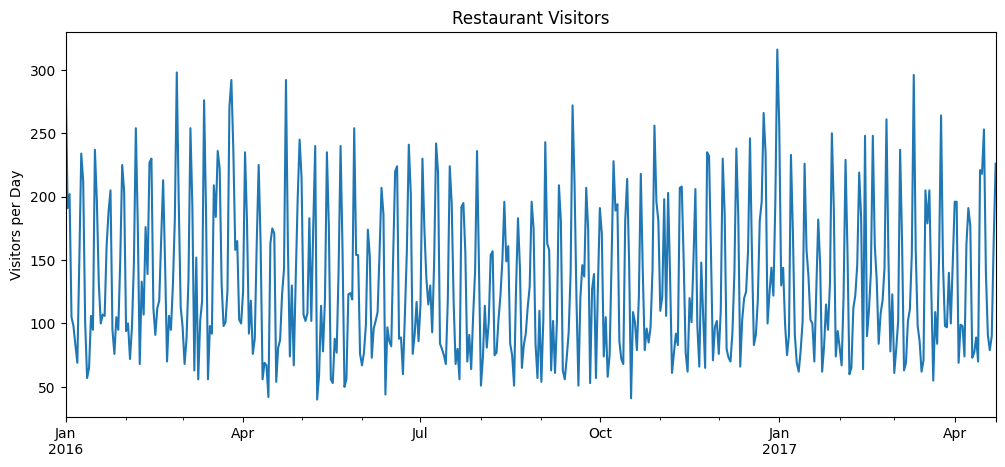

In [36]:
title = 'Restaurant Visitors'
xlabel = ''
ylabel = 'Visitors per Day'

ax = df1['total'].plot(title=title)
ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel,ylabel=ylabel);

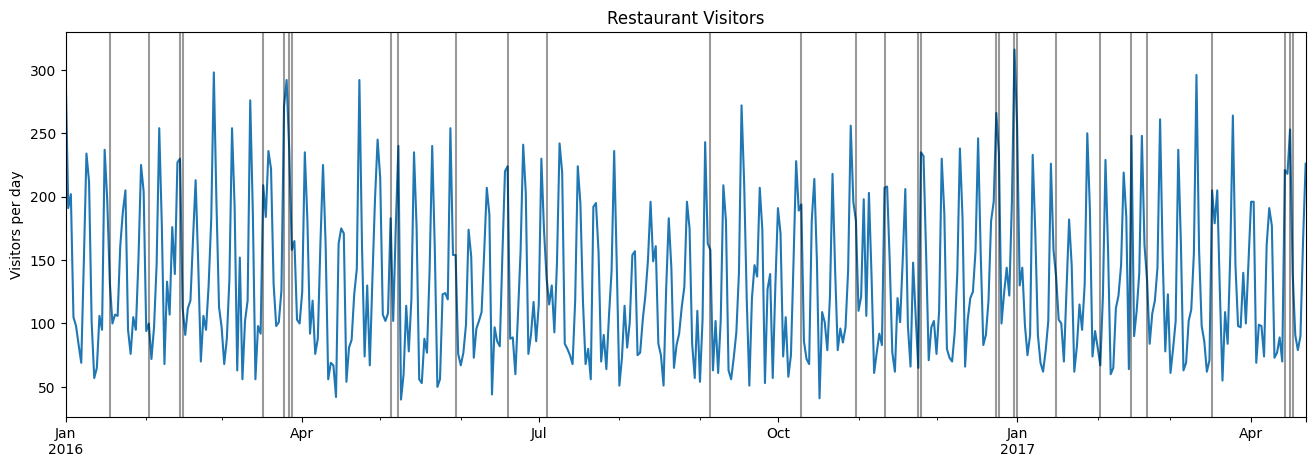

In [37]:
title = 'Restaurant Visitors'
ylabel = 'Visitors per day'
xlabel = '' 

ax = df1['total'].plot(figsize=(16,5),title=title)
ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)
for i in df1[df1['holiday']==1].index:
    ax.axvline(x=i,color='k',alpha=0.4)

In [46]:
result = seasonal_decompose(df1['total'], period = 28)

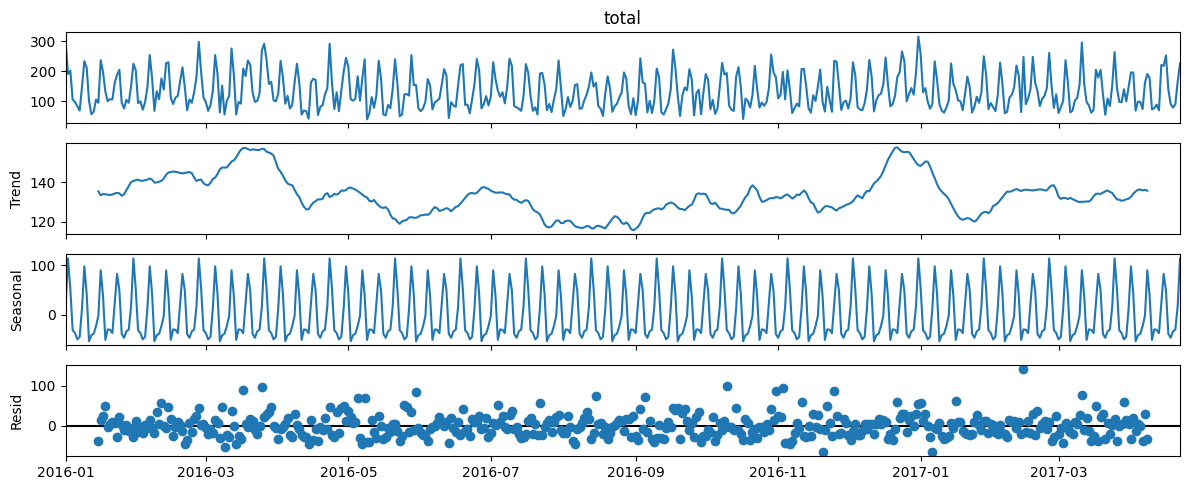

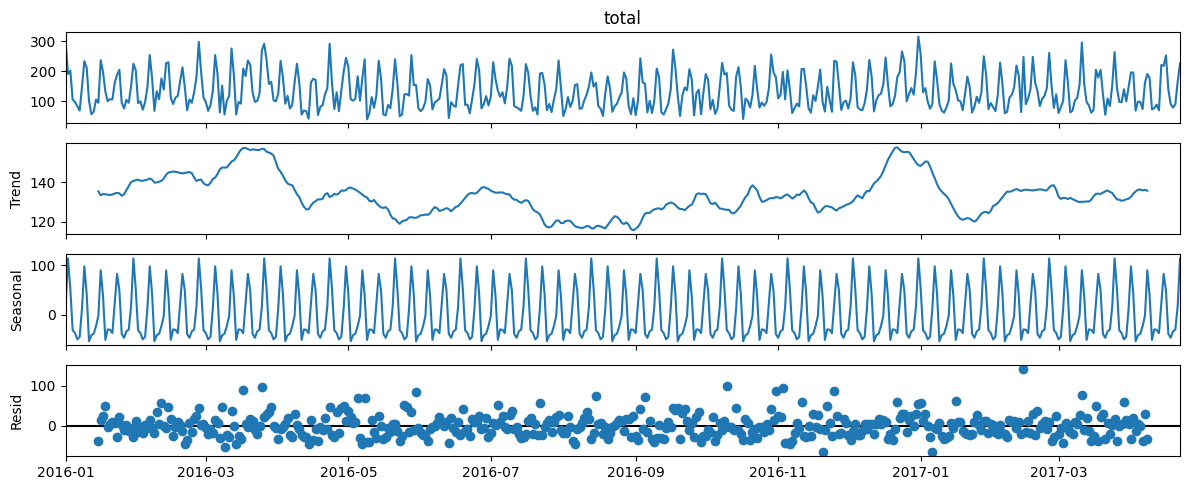

In [47]:
result.plot()

In [48]:
from statsmodels.tsa.stattools import adfuller

In [49]:
def dickey_fuller(series,title='Dickey Fuller test of your dataset reveals the following about stationarity'):
    '''This function takes a series and returns whether the time series is stationary or not.
    The result is based on the p-value returned by the dickey fuller test    
    '''
    
    print(f'Test of Stationarity using Dickey Fuller Test of the dataset {title}')
    result = adfuller(series.dropna(),autolag='AIC')
    labels = ['ADF test statistics','p-value','#lags','# observations']
    
    out = pd.Series(data=result[0:4],index=labels)
    
    for key,val in result[4].items():
        out[f'critical value ({key})'] = val
        
    print(out.to_string())
    
    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis")
        print("Reject the null hypothesis")
        print("Data has no unit root and is stationary")
    else:
        print("Weak evidence against the null hypothesis")
        print("Fail to reject the null hypothesis")
        print("Data has a unit root and is non-stationary")         
    

In [50]:
dickey_fuller(df1['total'])

Test of Stationarity using Dickey Fuller Test of the dataset Dickey Fuller test of your dataset reveals the following about stationarity
ADF test statistics      -5.592497
p-value                   0.000001
#lags                    18.000000
# observations          459.000000
critical value (1%)      -3.444677
critical value (5%)      -2.867857
critical value (10%)     -2.570135
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary


In [ ]:
warnings.filterwarnings(action='ignore',message='')
auto_arima(df1['total'],
           seasonal=True,
           m = 7, 
           information_criterion='bic').summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 SARIMAX Results                                 
=================================================================================
Dep. Variable:                         y   No. Observations:                  478
Model:             SARIMAX(1, 0, [1], 7)   Log Likelihood               -2382.855
Date:                   Mon, 16 Mar 2026   AIC                           4773.709
Time:                           14:47:39   BIC                           4790.388
Sample:                       01-01-2016   HQIC                          4780.267
                            - 04-22-2017                                         
Covariance Type:                     opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      4.2508      1.544      2.753      0.006       1.224       7.277
ar.S.L7        0.9653      0.012     80.602      0.000       0.942       0.989
ma.S.L7       -0.7464      0.048    -15.538      0.000      -0.841      -0.652
sigma2      1190.7014     69.102     17.231      0.000    1055.264    1326.139
===================================================================================
Ljung-Box (L1) (Q):                  15.26   Jarque-Bera (JB):                64.48
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.86   Skew:                             0.74
Prob(H) (two-sided):                  0.34   Kurtosis:                         4.02
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [52]:
train = df1.iloc[:int(0.8*len(df1))]
test = df1.iloc[int(0.8*len(df1)):]

## Fit the SARIMAX Model

In [ ]:
model = SARIMAX(train['total'],
                order=(1,0,0),
                seasonal_order=(1,0,1,7),
                enforce_invertibility=False)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                               total   No. Observations:                  382
Model:             SARIMAX(1, 0, 0)x(1, 0, [1], 7)   Log Likelihood               -1891.824
Date:                             Mon, 16 Mar 2026   AIC                           3791.648
Time:                                     14:48:18   BIC                           3807.430
Sample:                                 01-01-2016   HQIC                          3797.909
                                      - 01-16-2017                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2443      0.046      5.328      0.000       0.154       0.334
ar.S.L7        0.9999      0.000   7563.208      0.000       1.000       1.000
ma.S.L7       -0.9433      0.025    -37.617      0.000      -0.992      -0.894
sigma2      1076.2012     70.383     15.291      0.000     938.253    1214.149
===================================================================================
Ljung-Box (L1) (Q):                   1.02   Jarque-Bera (JB):                30.19
Prob(Q):                              0.31   Prob(JB):                         0.00
Heteroskedasticity (H):               0.96   Skew:                             0.55
Prob(H) (two-sided):                  0.80   Kurtosis:                         3.82
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [54]:
start = len(train)
end = len(train) + len(test) - 1
predictions = results.predict(start=start,end=end,dynamic=False).rename('SARIMA(1,0,0)(1,0,[1],7) Predictions')

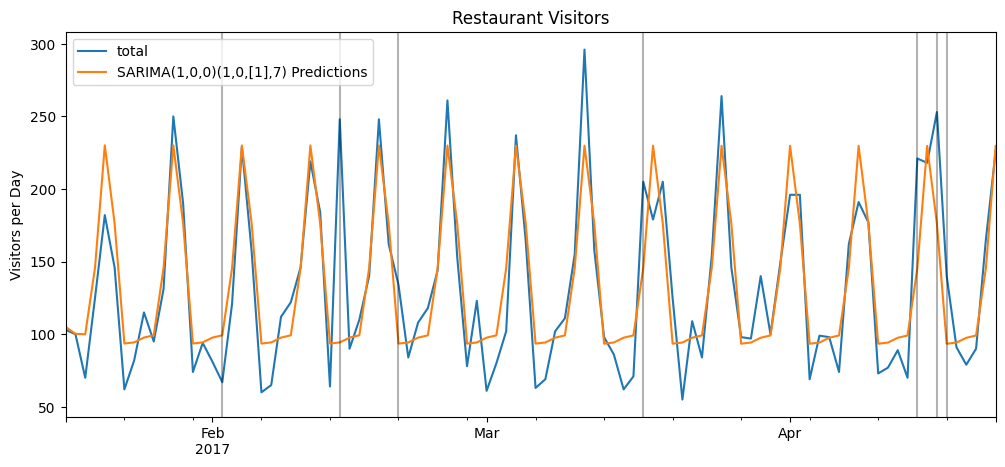

In [55]:
title = 'Restaurant Visitors'
ylabel = 'Visitors per Day'
xlabel = ''

ax = test['total'].plot(legend=True,title=title)
predictions.plot(legend=True)
ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel,ylabel=ylabel)
for x in test[test['holiday']==1].index:
    ax.axvline(x=x,color='k',alpha=0.3)

In [56]:
from statsmodels.tools.eval_measures import mse,rmse

In [57]:
mse_error = mse(test['total'],predictions)
rmse_error = rmse(test['total'],predictions)

In [58]:
print(f'SARIMA(1,0,0)(1,0,[1],7) MSE Error: {mse_error:11.10}')
print(f'SARIMA(1,0,0)(0,0,[1],7) RMSE Error: {rmse_error:11.10}')

SARIMA(1,0,0)(1,0,[1],7) MSE Error: 934.4702797
SARIMA(1,0,0)(0,0,[1],7) RMSE Error: 30.56910662


In [59]:
model = SARIMAX(train['total'],
                exog=train['holiday'],
                order=(1,0,0),
                seasonal_order=(1,0,[1],7),
                enforce_invertibility=False)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                               total   No. Observations:                  382
Model:             SARIMAX(1, 0, 0)x(1, 0, [1], 7)   Log Likelihood               -1834.273
Date:                             Mon, 16 Mar 2026   AIC                           3678.546
Time:                                     14:49:33   BIC                           3698.273
Sample:                                 01-01-2016   HQIC                          3686.372
                                      - 01-16-2017                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
holiday       68.6329      4.849     14.155      0.000      59.130      78.136
ar.L1          0.2170      0.046      4.767      0.000       0.128       0.306
ar.S.L7        0.9999   8.22e-05   1.22e+04      0.000       1.000       1.000
ma.S.L7       -0.9510      0.024    -39.068      0.000      -0.999      -0.903
sigma2       788.9530     52.899     14.914      0.000     685.272     892.634
===================================================================================
Ljung-Box (L1) (Q):                   0.16   Jarque-Bera (JB):                11.23
Prob(Q):                              0.69   Prob(JB):                         0.00
Heteroskedasticity (H):               0.99   Skew:                             0.24
Prob(H) (two-sided):                  0.97   Kurtosis:                         3.69
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [60]:
# Obtain the predicted values
start = len(train)
end = len(train)+len(test)-1
exog_forecast = test[['holiday']] ## requires two brackets to yield a shape of (35,1), print test[['holiday']] if you like
predictions =  results.predict(start=start,end=end,exog=exog_forecast).rename('SARIMAX(1,0,0)(1,0,[1],7) Predictions')


In [61]:
test[['holiday']][:10]

,holiday
date,
2017-01-17,0
2017-01-18,0
2017-01-19,0
2017-01-20,0
2017-01-21,0
2017-01-22,0
2017-01-23,0
2017-01-24,0
2017-01-25,0


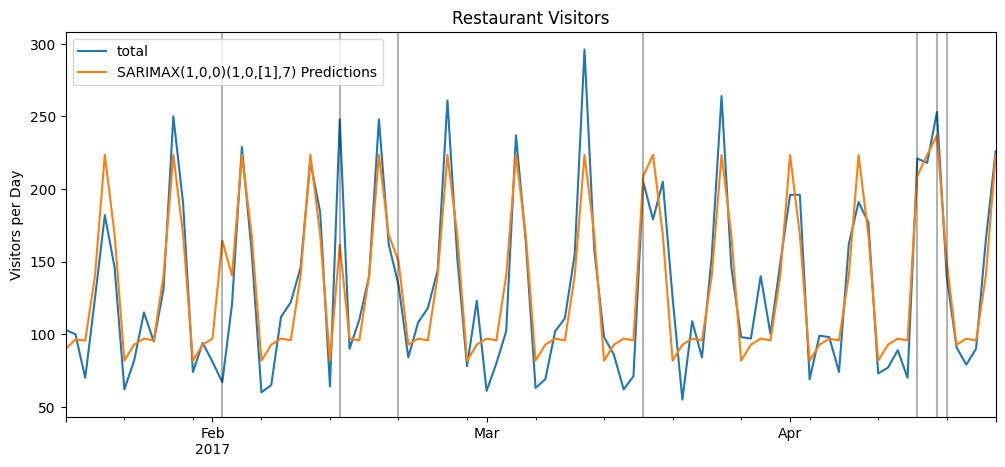

In [62]:
title = 'Restaurant Visitors'
ylabel = 'Visitors per Day'
xlabel = ''

ax = test['total'].plot(legend=True,title=title)
predictions.plot(legend=True)
ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel,ylabel=ylabel)
for x in test[test['holiday']==1].index:
    ax.axvline(x=x,color='k',alpha=0.3)

In [63]:
print(f'SARIMA(1,0,0)(2,0,0,7) MSE Error: {mse_error:11.10}')
print(f'SARIMA(1,0,0)(2,0,0,7) RMSE Error: {rmse_error:11.10}')
print()

mse_error_x = mse(test['total'], predictions)
rmse_error_x = rmse(test['total'], predictions)

print(f'SARIMAX(1,0,0)(2,0,0,7) MSE Error: {mse_error_x:11.10}')
print(f'SARIMAX(1,0,0)(2,0,0,7) RMSE Error: {rmse_error_x:11.10}')

SARIMA(1,0,0)(2,0,0,7) MSE Error: 934.4702797
SARIMA(1,0,0)(2,0,0,7) RMSE Error: 30.56910662

SARIMAX(1,0,0)(2,0,0,7) MSE Error: 628.9563735
SARIMAX(1,0,0)(2,0,0,7) RMSE Error: 25.07900264


In [ ]:
model = SARIMAX(df1['total'],
                exog=df1['holiday'],
                order=(1,0,0),
                seasonal_order=(1,0,1,7),
                enforce_invertibility=False)
results = model.fit()
exog_forecast = df[478:][['holiday']] ## forecast into the original dataframe where the values were NaN for visitors
fcast = results.predict(len(df1),len(df1)+38,exog=exog_forecast).rename('SARIMAX(1,0,0)(2,0,0,7) Forecast')

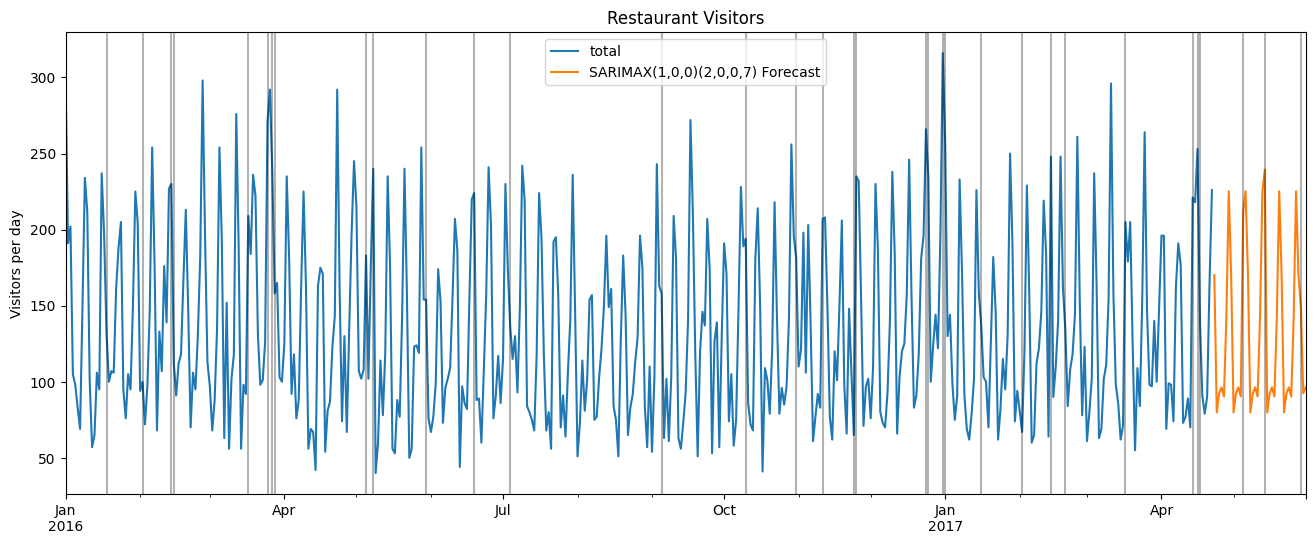

In [65]:
title='Restaurant Visitors'
ylabel='Visitors per day'
xlabel=''

ax = df1['total'].plot(legend=True,figsize=(16,6),title=title)
fcast.plot(legend=True)
ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)
for x in df.query('holiday==1').index: 
    ax.axvline(x=x, color='k', alpha = 0.3);